In [23]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [9]:
#导入数据
print(os.getcwd())
os.chdir("E:\python\project\python\随堂\pandas")
df=pd.read_excel('./data/sales_test.xlsx',index_col="USERID")
print(df)
df.isna().sum() # 判断空值

E:\python\project\python\随堂\pandas
        ORDERDATE  ORDERID  AMOUNTINFO
USERID                                
1      2023-05-01       11      1000.0
2      2023-04-02       22      2000.0
3      2023-04-03       33      3000.0
4      2023-04-04       44      4000.0
5      2023-04-05       55      5000.0
6      2023-04-05       66         NaN
2      2022-04-02       77       300.0
2      2022-04-23       88       800.0
6      2022-04-23       99      1500.0


ORDERDATE     0
ORDERID       0
AMOUNTINFO    1
dtype: int64

In [10]:
# 删除空值
df1=df.dropna()
df1.head(10)

,ORDERDATE,ORDERID,AMOUNTINFO
USERID,,,
1,2023-05-01,11,1000.0
2,2023-04-02,22,2000.0
3,2023-04-03,33,3000.0
4,2023-04-04,44,4000.0
5,2023-04-05,55,5000.0
2,2022-04-02,77,300.0
2,2022-04-23,88,800.0
6,2022-04-23,99,1500.0


In [11]:
# 去除非法值(订单金额小于1的)
cdf=df1[df1["AMOUNTINFO"]>1]
cdf

,ORDERDATE,ORDERID,AMOUNTINFO
USERID,,,
1,2023-05-01,11,1000.0
2,2023-04-02,22,2000.0
3,2023-04-03,33,3000.0
4,2023-04-04,44,4000.0
5,2023-04-05,55,5000.0
2,2022-04-02,77,300.0
2,2022-04-23,88,800.0
6,2022-04-23,99,1500.0


In [14]:
#  数据转换 (按用户ID去重归总)
# 计算最近一次订单时间
recent_value=cdf["ORDERDATE"].groupby(cdf.index).max()
print(recent_value)
# 计算订单频率
frequency_value=cdf["ORDERDATE"].groupby(cdf.index).count()
print(frequency_value)
#计算订单总金额
monetary_value=cdf["AMOUNTINFO"].groupby(cdf.index).sum()
monetary_value

USERID
1   2023-05-01
2   2023-04-02
3   2023-04-03
4   2023-04-04
5   2023-04-05
6   2022-04-23
Name: ORDERDATE, dtype: datetime64[ns]
USERID
1    1
2    3
3    1
4    1
5    1
6    1
Name: ORDERDATE, dtype: int64


USERID
1    1000.0
2    3100.0
3    3000.0
4    4000.0
5    5000.0
6    1500.0
Name: AMOUNTINFO, dtype: float64

In [15]:
deadline_date = pd.to_datetime("2024-12-29")
# deadline_date
r_interval = (deadline_date - recent_value).dt.days  # 计算 R 间隔
r_score = pd.cut(r_interval, 5, labels=[5, 4, 3, 2, 1])  # 计算 R 得分，五分位倒序
f_score = pd.cut(frequency_value, 5, labels=[1, 2, 3, 4, 5])  # 计算 F 得分
m_score = pd.cut(monetary_value, 5, labels=[1, 2, 3, 4, 5])  # 计算 M 得分

In [17]:
# R, F, M 数据合并
rfm_list = [r_score, f_score, m_score]  # 将 R, F, M 三个维度组成列表
rfm_cols = ['r_score', 'f_score', 'm_score']  # 设置 R, F, M 三个维度的列名
rfm_pd = pd.DataFrame(np.array(rfm_list).transpose(), dtype=np.int32, columns=rfm_cols, index=frequency_value.index)  # 建立 R, F, M 数据框

In [19]:
# 策略1：加权得分 定义用户价值
rfm_pd['rfm_wscore'] = rfm_pd['r_score']*0.2 + rfm_pd['f_score']*0.2 + rfm_pd['m_score']*0.6

In [21]:
# 策略2：RFM组合 直接输出三维度值
rfm_pd_tmp = rfm_pd.copy()
rfm_pd_tmp['r_score'] = rfm_pd_tmp['r_score'].astype('str')
rfm_pd_tmp['f_score'] = rfm_pd_tmp['f_score'].astype('str')
rfm_pd_tmp['m_score'] = rfm_pd_tmp['m_score'].astype('str')
rfm_pd['rfm_comb'] = rfm_pd_tmp['r_score'].str.cat(rfm_pd_tmp['f_score']).str.cat(rfm_pd_tmp['m_score'])

In [22]:
#导出数据
rfm_pd.to_csv('rfm_result.csv')

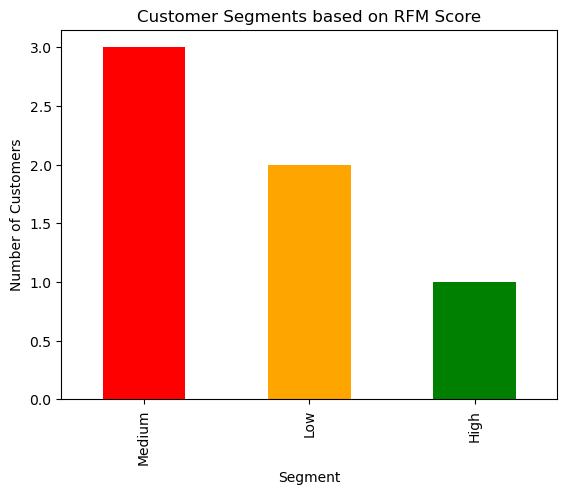

In [26]:
# 可视化图
# 根据加权得分划分客户群体
bins = [0, 2, 4, 5]  # 自定义分层阈值
labels = ['Low', 'Medium', 'High']  # 分层标签
rfm_pd['Customer Segment'] = pd.cut(rfm_pd['rfm_wscore'], bins=bins, labels=labels)

# 绘制柱状图
rfm_pd['Customer Segment'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Customer Segments based on RFM Score')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()




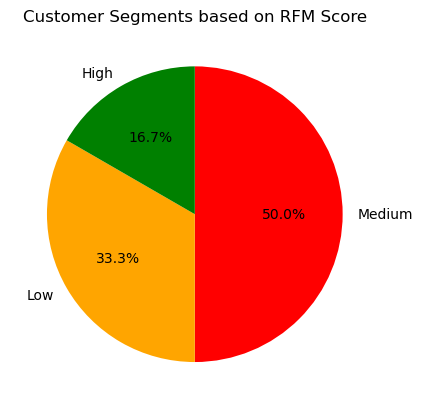

In [28]:
bins = [0, 2, 4, 5]  # 自定义分层阈值
labels = ['Low', 'Medium', 'High']  # 分层标签
rfm_pd['Customer Segment'] = pd.cut(rfm_pd['rfm_wscore'], bins=bins, labels=labels)

# 绘制饼状图
rfm_pd['Customer Segment'].value_counts().plot(kind='pie',colors=['red', 'orange', 'green'],autopct='%1.1f%%', startangle=90, counterclock=False) # 顺时针方向
plt.title('Customer Segments based on RFM Score')
plt.ylabel('')  # 隐藏Y轴标签
plt.show()